In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt

In [2]:
# Grid world dimensions and parameters
grid_height = 5
grid_width = 7
start_state = (0, 0)
goal_state = (4, 6)
static_obstacles = [(2, 2), (3, 3)]  # Static obstacles
moving_obstacles = [(1, 1), (3, 4)]  # Moving obstacles with periodic motion
action_map = {'UP': (-1, 0), 'DOWN': (1, 0), 'LEFT': (0, -1), 'RIGHT': (0, 1)}
actions = list(action_map.keys())

In [3]:
# Neural network models for Actor and Critic
class ActorNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, state):
        return self.fc(state)

In [4]:
class CriticNetwork(nn.Module):
    def __init__(self, state_dim):
        super(CriticNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, state):
        return self.fc(state)

In [5]:
# Initialize networks, optimizers, and loss
state_dim = 2  # (x, y) coordinates
action_dim = len(actions)

actor = ActorNetwork(state_dim, action_dim)
critic = CriticNetwork(state_dim)

actor_optimizer = optim.Adam(actor.parameters(), lr=0.001)
critic_optimizer = optim.Adam(critic.parameters(), lr=0.001)
criterion = nn.MSELoss()

gamma = 0.99  # Discount factor
learning_rate = 0.001

In [6]:
# Function to choose an action based on policy
def choose_action(state):
    state_tensor = torch.tensor(state, dtype=torch.float32)
    action_probs = actor(state_tensor)
    action = np.random.choice(len(actions), p=action_probs.detach().numpy())
    return action

In [7]:
# Moving obstacle update
def update_moving_obstacles(obstacles):
    for i, obs in enumerate(obstacles):
        if i % 2 == 0:  # Even-index obstacles move horizontally
            obstacles[i] = (obs[0], (obs[1] + 1) % grid_width)
        else:  # Odd-index obstacles move vertically
            obstacles[i] = ((obs[0] + 1) % grid_height, obs[1])
    return obstacles

In [14]:
# Training loop for ADP
def adp_training(episodes=50, max_steps=200):
    all_paths = []
    mse_per_episode = []
    reward_log = []  # Store rewards per episode
    step_log = []    # Store steps per episode

    for episode in range(episodes):
        state = start_state
        steps = 0
        agent_path = [state]
        episode_loss = 0
        episode_reward = 0  # Track reward for the current episode
        moving_obstacles_copy = moving_obstacles[:]

        print(f"--- Episode {episode + 1} ---")

        while state != goal_state and steps < max_steps:
            # Convert state to tensor
            state_tensor = torch.tensor(state, dtype=torch.float32)

            # Choose action using the actor
            action = choose_action(state_tensor)
            next_state = tuple(np.add(state, action_map[actions[action]]))

            # Check validity of the move
            if (next_state[0] < 0 or next_state[0] >= grid_height or
                    next_state[1] < 0 or next_state[1] >= grid_width or
                    next_state in static_obstacles or next_state in moving_obstacles_copy):
                reward = -10
                next_state = state  # Stay in the current state
            elif next_state == goal_state:
                reward = 100
            else:
                reward = -1

            # Compute TD error and update networks
            next_state_tensor = torch.tensor(next_state, dtype=torch.float32)
            state_value = critic(state_tensor)
            next_state_value = critic(next_state_tensor).detach()
            td_target = reward + gamma * next_state_value
            td_error = td_target - state_value

            # Update Critic
            critic_loss = criterion(state_value, td_target)
            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()

            # Update Actor
            action_probs = actor(state_tensor)
            log_prob = torch.log(action_probs[action])
            actor_loss = -log_prob * td_error.detach()  # Use TD error as feedback
            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()

            # Accumulate loss and reward
            episode_loss += critic_loss.item()
            episode_reward += reward  # Accumulate episode rewards
            state = next_state
            agent_path.append(state)
            steps += 1

            print(f"Step {steps}: Moved from {agent_path[-2]} to {state} with reward {reward}")

            # Update moving obstacles
            moving_obstacles_copy = update_moving_obstacles(moving_obstacles_copy)

        # Append metrics for this episode
        all_paths.append(agent_path)
        mse_per_episode.append(episode_loss / steps if steps > 0 else 0)
        reward_log.append(episode_reward)  # Add total reward for this episode
        step_log.append(steps)            # Add total steps for this episode

        print(f"Episode {episode + 1} complete. Total Steps: {steps}")

        # Visualize the grid world
        plot_grid_world(state, goal_state, static_obstacles + moving_obstacles_copy, agent_path)

    return all_paths, mse_per_episode, reward_log, step_log

In [9]:
# Visualization function
def plot_grid_world(agent_pos, goal_pos, obstacles, path):
    grid = np.zeros((grid_height, grid_width))
    grid[goal_pos] = 1  # Goal
    for obs in obstacles:
        grid[obs] = -1  # Obstacles

    plt.figure(figsize=(6, 4))
    plt.imshow(grid, cmap='BuPu', origin='upper')
    plt.scatter(agent_pos[1], agent_pos[0], color='green', s=200, label='Agent')
    plt.scatter(goal_pos[1], goal_pos[0], color='yellow', s=200, label='Goal')

    if path:
        path_x, path_y = zip(*path)
        plt.plot(path_y, path_x, color='red', marker='o', markersize=5, label='Path')

    plt.xticks(range(grid_width))
    plt.yticks(range(grid_height))
    plt.grid()
    plt.legend()
    plt.title('Grid World with Agent Path')
    plt.show()

--- Episode 1 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
Ste

<ipython-input-6-72b5c2eb8f2b>:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_tensor = torch.tensor(state, dtype=torch.float32)


Step 55: Moved from (0, 0) to (0, 1) with reward -1
Step 56: Moved from (0, 1) to (0, 0) with reward -1
Step 57: Moved from (0, 0) to (0, 1) with reward -1
Step 58: Moved from (0, 1) to (0, 2) with reward -1
Step 59: Moved from (0, 2) to (0, 1) with reward -1
Step 60: Moved from (0, 1) to (0, 2) with reward -1
Step 61: Moved from (0, 2) to (0, 1) with reward -1
Step 62: Moved from (0, 1) to (0, 0) with reward -1
Step 63: Moved from (0, 0) to (0, 1) with reward -1
Step 64: Moved from (0, 1) to (0, 2) with reward -1
Step 65: Moved from (0, 2) to (0, 1) with reward -1
Step 66: Moved from (0, 1) to (0, 0) with reward -1
Step 67: Moved from (0, 0) to (0, 1) with reward -1
Step 68: Moved from (0, 1) to (0, 0) with reward -1
Step 69: Moved from (0, 0) to (0, 1) with reward -1
Step 70: Moved from (0, 1) to (0, 2) with reward -1
Step 71: Moved from (0, 2) to (0, 1) with reward -1
Step 72: Moved from (0, 1) to (0, 0) with reward -1
Step 73: Moved from (0, 0) to (0, 1) with reward -1
Step 74: Mov

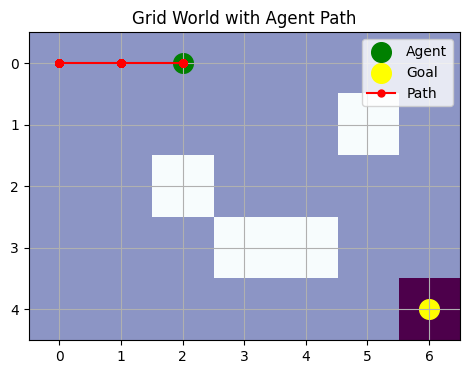

--- Episode 2 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
Ste

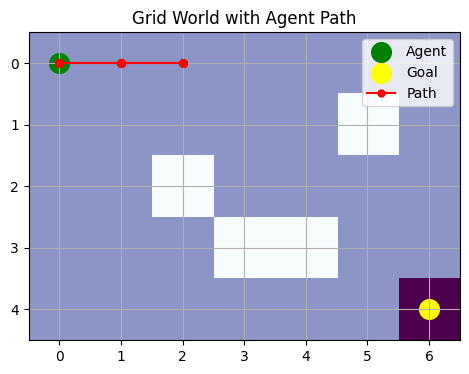

--- Episode 3 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
Ste

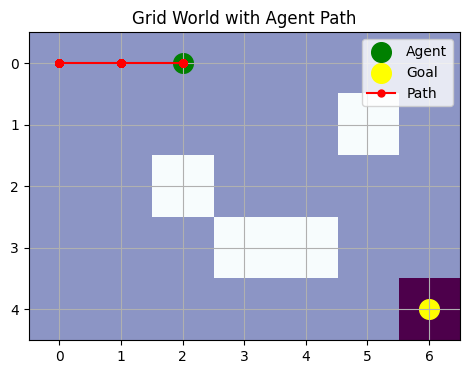

--- Episode 4 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
Ste

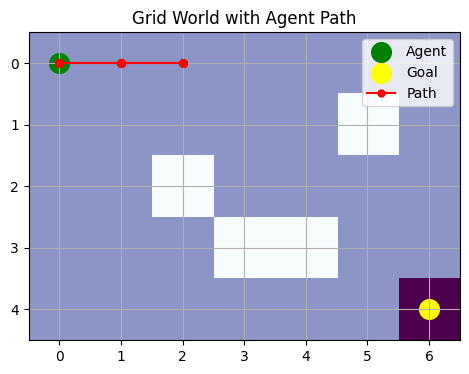

--- Episode 5 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
Ste

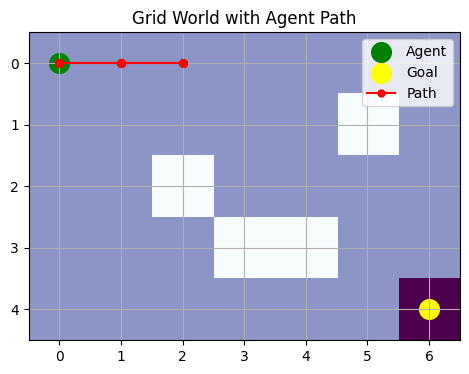

--- Episode 6 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
Ste

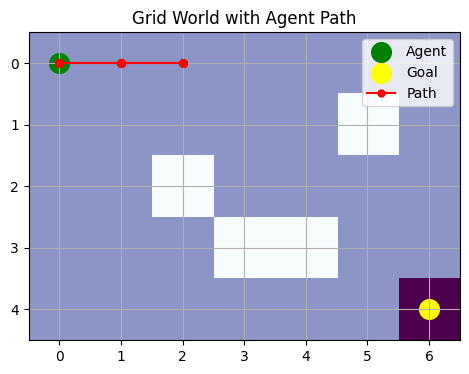

--- Episode 7 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
Ste

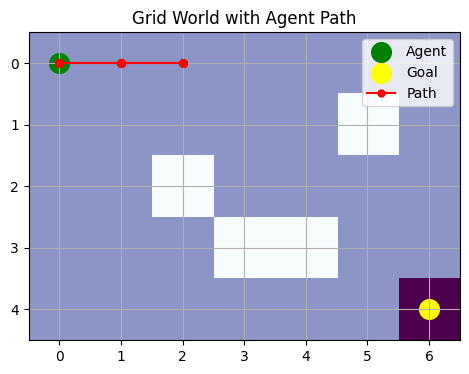

--- Episode 8 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
Ste

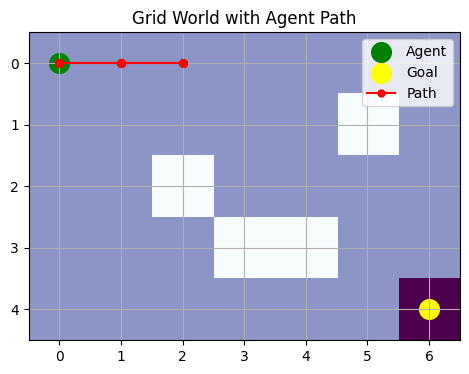

--- Episode 9 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
Ste

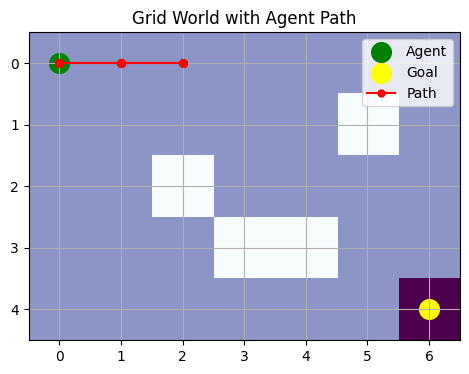

--- Episode 10 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

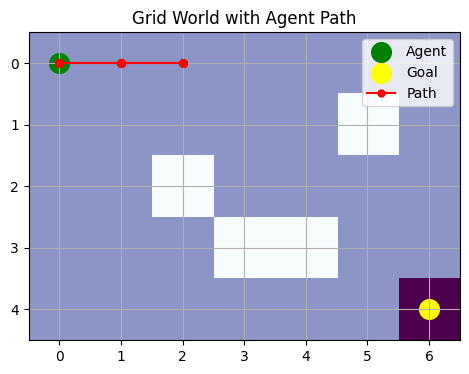

--- Episode 11 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

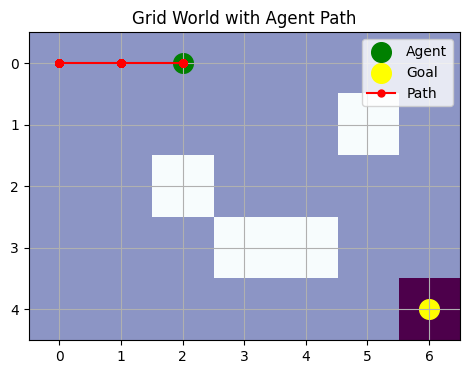

--- Episode 12 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

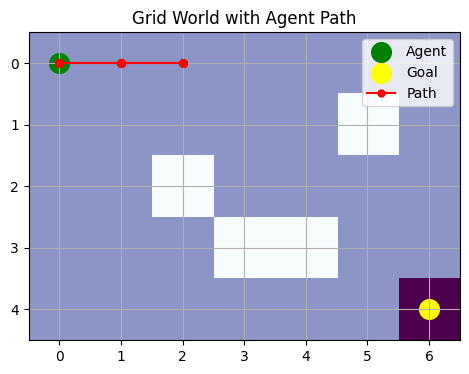

--- Episode 13 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

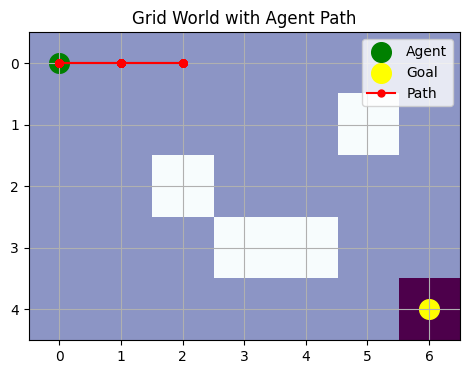

--- Episode 14 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

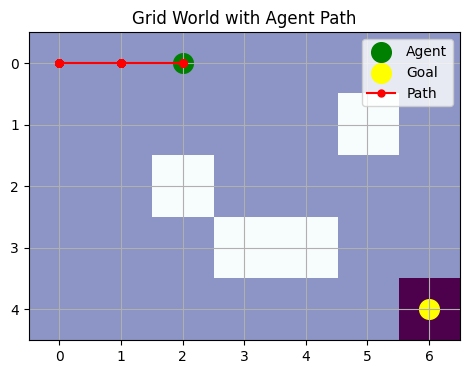

--- Episode 15 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

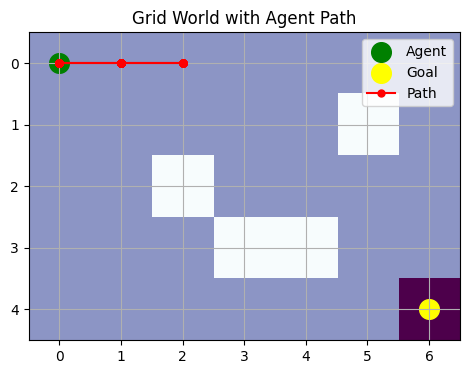

--- Episode 16 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

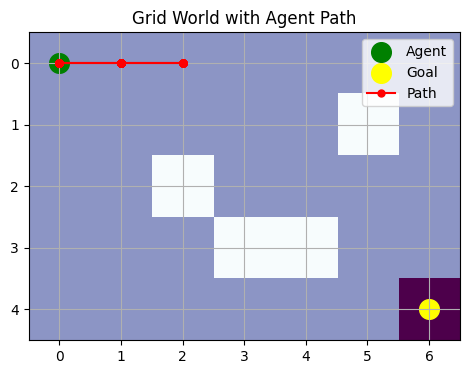

--- Episode 17 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

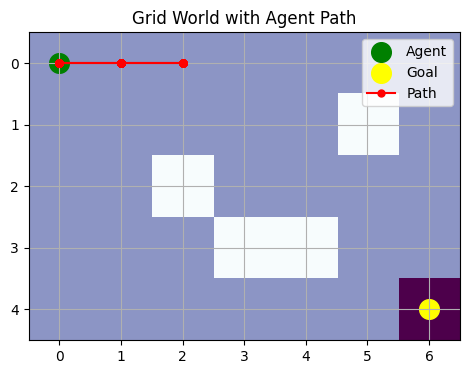

--- Episode 18 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

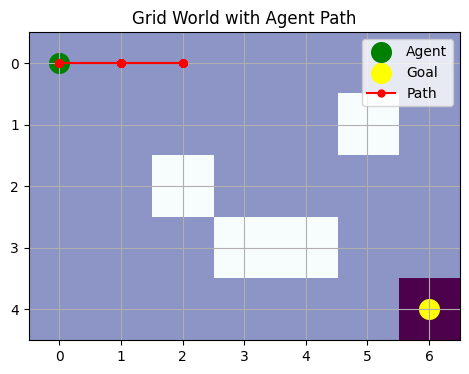

--- Episode 19 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

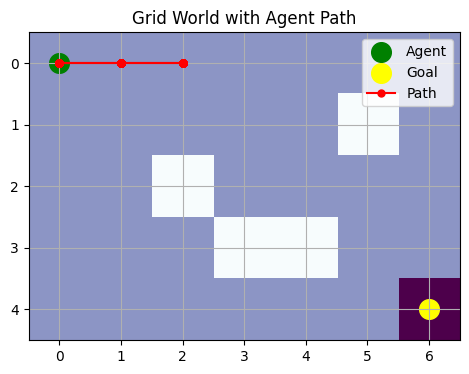

--- Episode 20 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

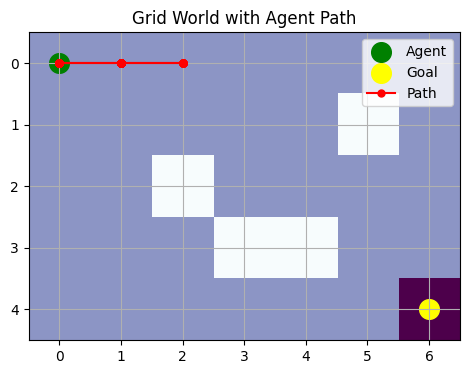

--- Episode 21 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

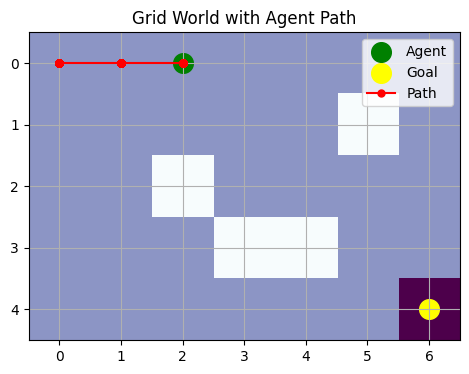

--- Episode 22 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

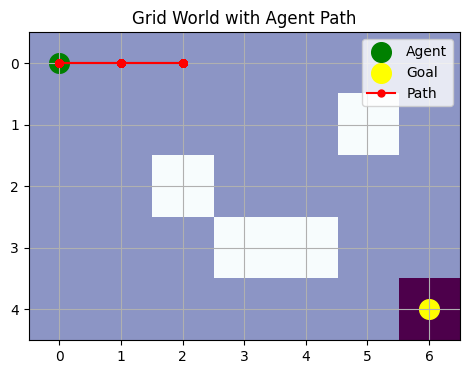

--- Episode 23 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

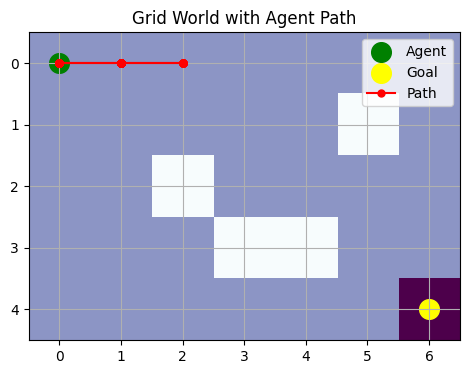

--- Episode 24 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

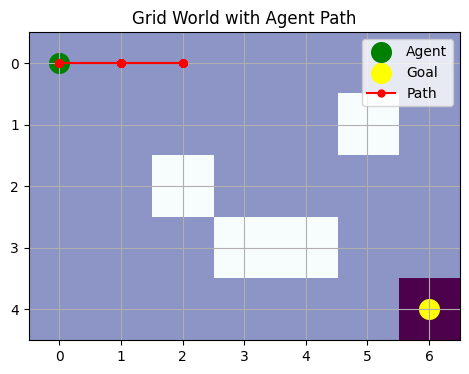

--- Episode 25 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

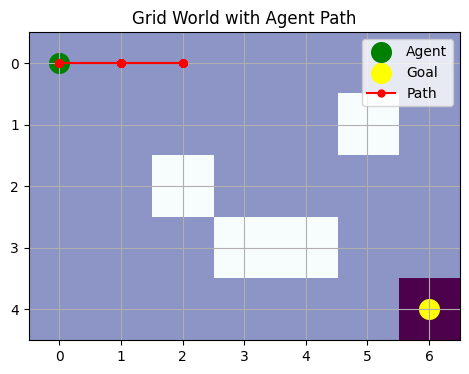

--- Episode 26 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

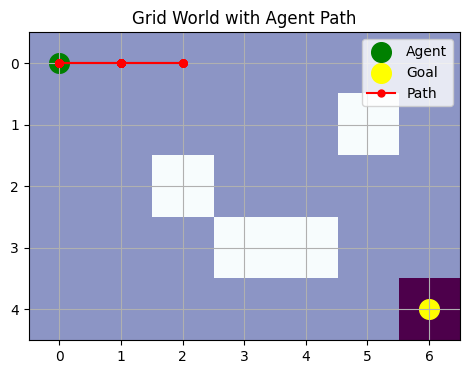

--- Episode 27 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

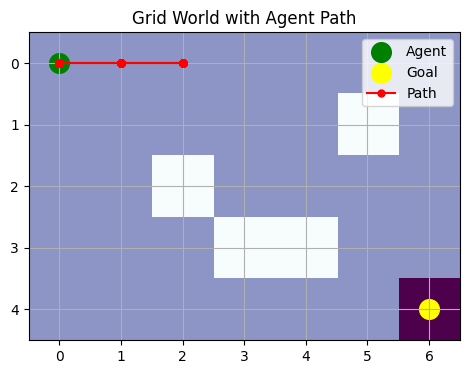

--- Episode 28 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

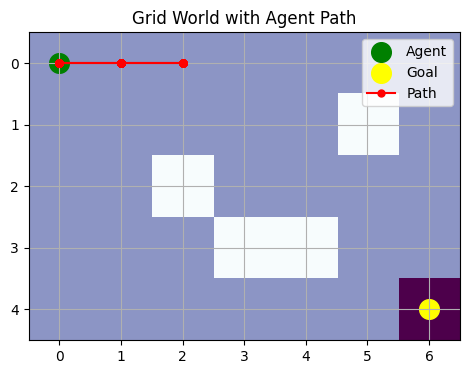

--- Episode 29 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

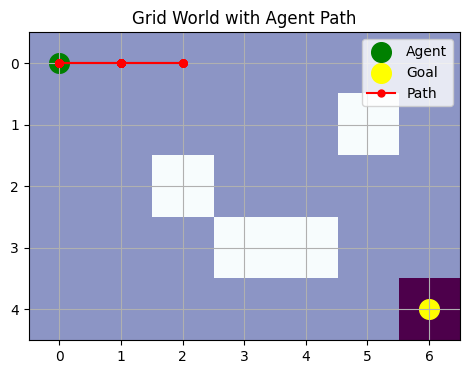

--- Episode 30 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

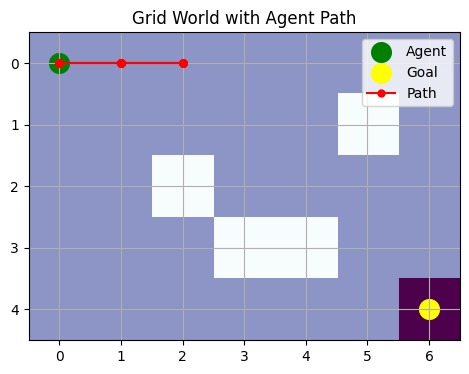

--- Episode 31 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

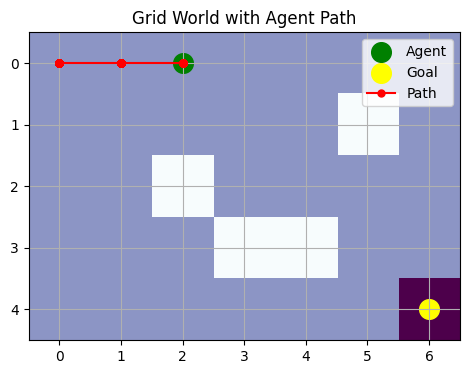

--- Episode 32 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

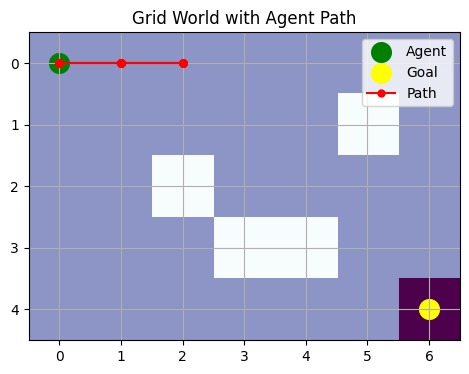

--- Episode 33 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

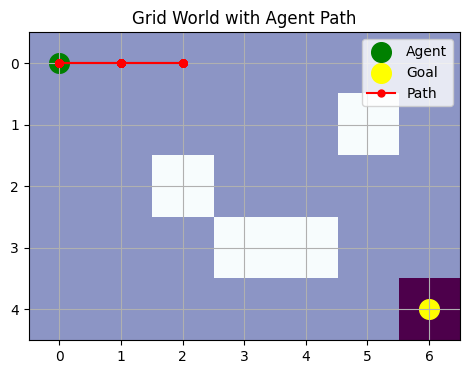

--- Episode 34 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

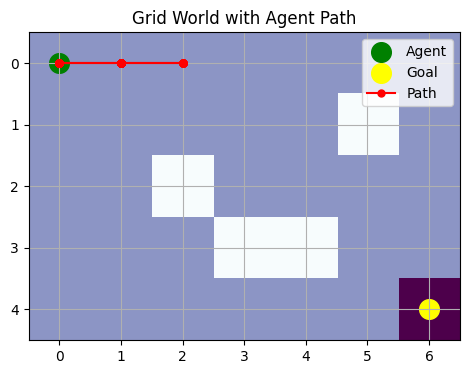

--- Episode 35 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

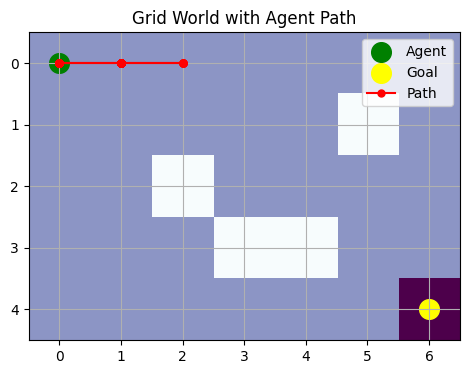

--- Episode 36 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

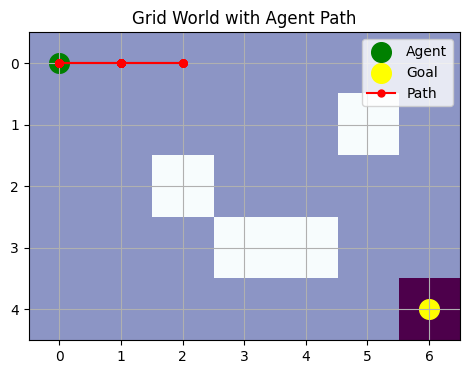

--- Episode 37 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

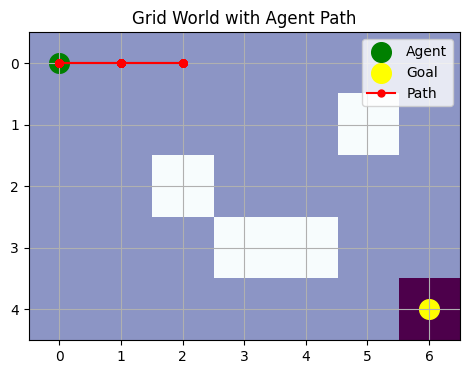

--- Episode 38 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

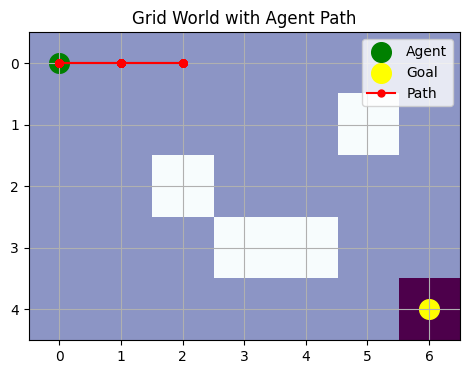

--- Episode 39 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

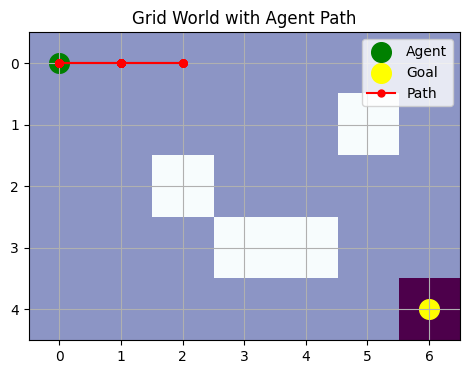

--- Episode 40 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

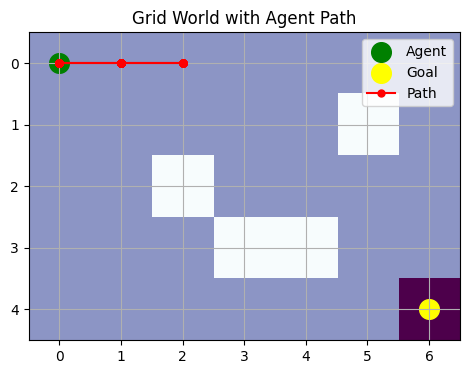

--- Episode 41 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 0) with reward -1
Step 15: Moved from (0, 0) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 0) with reward -1
Step 17: Moved from (0, 0) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

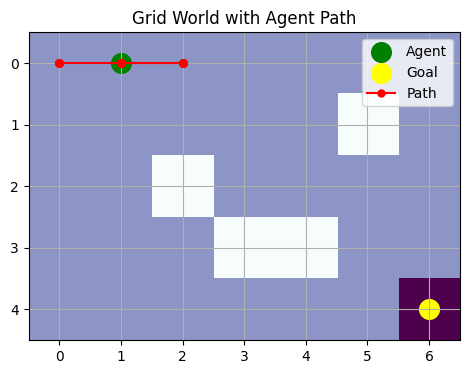

--- Episode 42 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

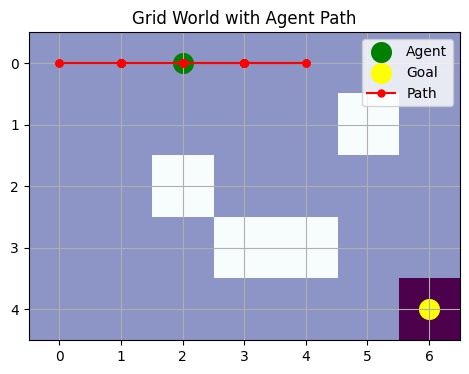

--- Episode 43 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 3) with reward -1
Step 4: Moved from (0, 3) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 3) with reward -1
Step 6: Moved from (0, 3) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 3) with reward -1
Step 8: Moved from (0, 3) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 3) with reward -1
Step 10: Moved from (0, 3) to (0, 4) with reward -1
Step 11: Moved from (0, 4) to (0, 3) with reward -1
Step 12: Moved from (0, 3) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 3) with reward -1
Step 14: Moved from (0, 3) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 3) with reward -1
Step 18: Moved from (0, 3) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 3) with reward -1
St

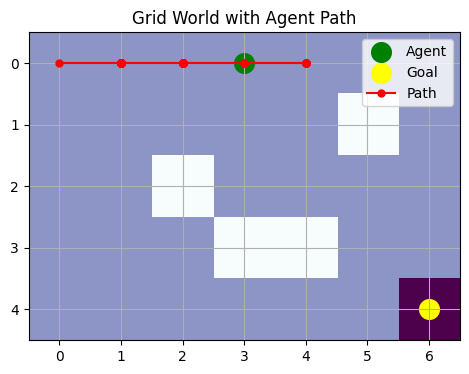

--- Episode 44 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 3) with reward -1
Step 4: Moved from (0, 3) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

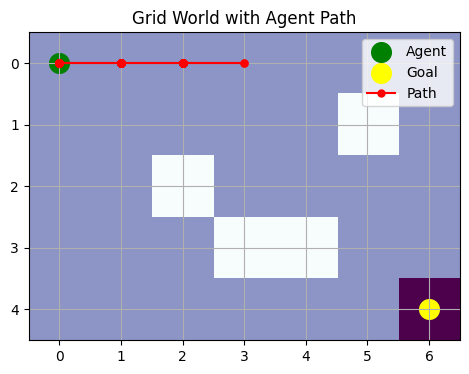

--- Episode 45 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

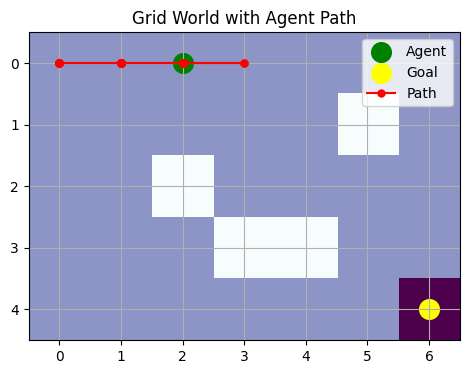

--- Episode 46 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 3) with reward -1
Step 8: Moved from (0, 3) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 0) with reward -1
Step 11: Moved from (0, 0) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

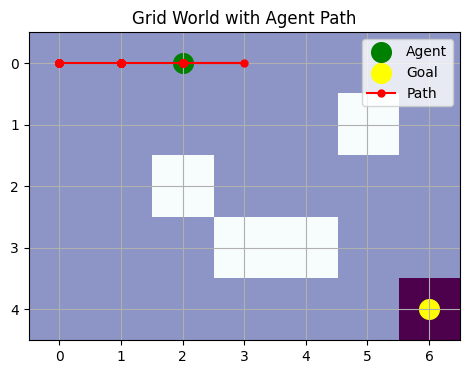

--- Episode 47 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

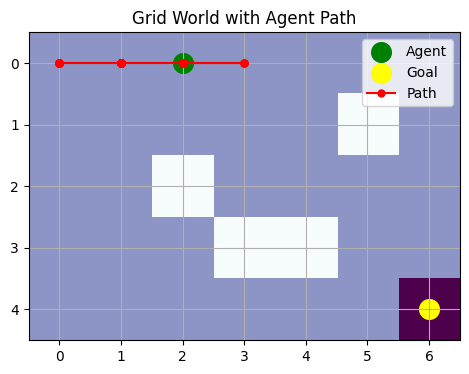

--- Episode 48 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 0) with reward -1
Step 9: Moved from (0, 0) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

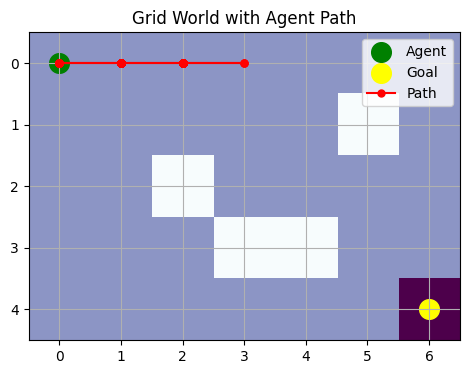

--- Episode 49 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 0) with reward -1
Step 19: Moved from (0, 0) to (0, 1) with reward -1
St

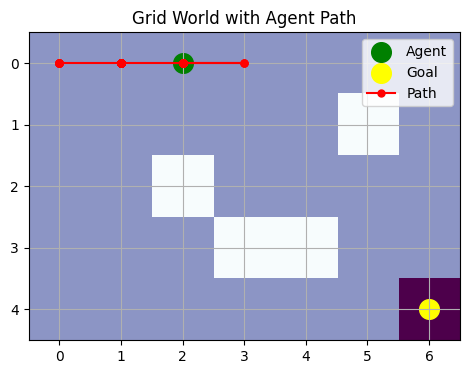

--- Episode 50 ---
Step 1: Moved from (0, 0) to (0, 1) with reward -1
Step 2: Moved from (0, 1) to (0, 2) with reward -1
Step 3: Moved from (0, 2) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 2) with reward -1
Step 5: Moved from (0, 2) to (0, 1) with reward -1
Step 6: Moved from (0, 1) to (0, 2) with reward -1
Step 7: Moved from (0, 2) to (0, 1) with reward -1
Step 8: Moved from (0, 1) to (0, 2) with reward -1
Step 9: Moved from (0, 2) to (0, 1) with reward -1
Step 10: Moved from (0, 1) to (0, 2) with reward -1
Step 11: Moved from (0, 2) to (0, 1) with reward -1
Step 12: Moved from (0, 1) to (0, 2) with reward -1
Step 13: Moved from (0, 2) to (0, 1) with reward -1
Step 14: Moved from (0, 1) to (0, 2) with reward -1
Step 15: Moved from (0, 2) to (0, 1) with reward -1
Step 16: Moved from (0, 1) to (0, 2) with reward -1
Step 17: Moved from (0, 2) to (0, 1) with reward -1
Step 18: Moved from (0, 1) to (0, 2) with reward -1
Step 19: Moved from (0, 2) to (0, 1) with reward -1
St

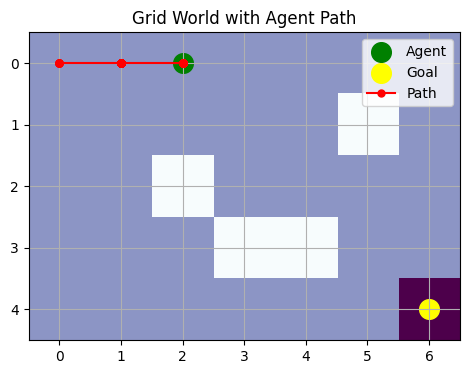

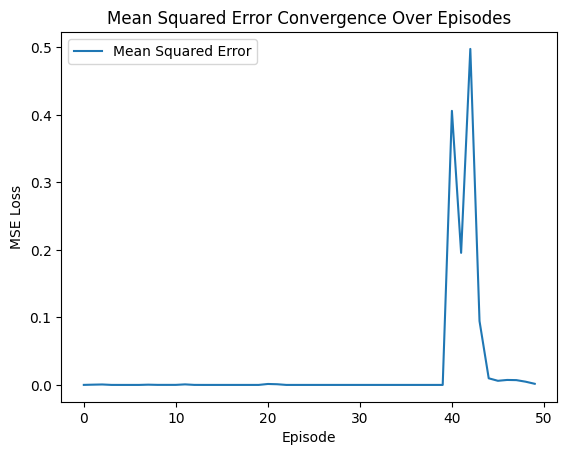

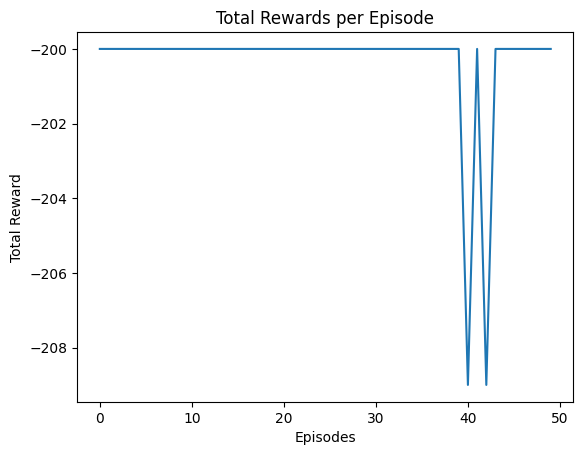

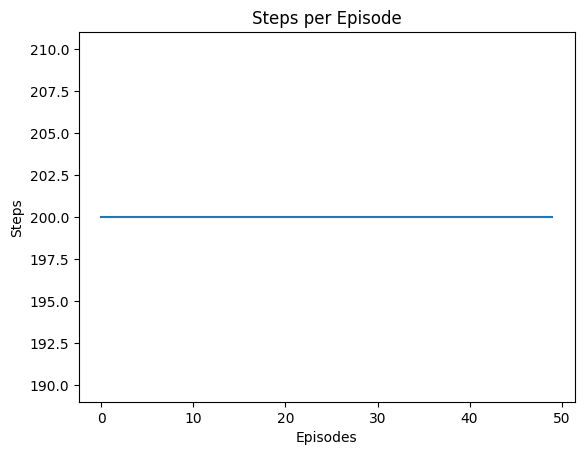

In [21]:
# Run ADP training
all_paths, mse_per_episode, reward_log, step_log = adp_training(episodes=50)  # Receive reward_log and step_log

# Plot MSE convergence
plt.figure()
plt.plot(mse_per_episode, label="Mean Squared Error")
plt.xlabel("Episode")
plt.ylabel("MSE Loss")
plt.title("Mean Squared Error Convergence Over Episodes")
plt.legend()
plt.show()

# Plot rewards
plt.figure()
plt.plot(reward_log)
plt.title("Total Rewards per Episode")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.show()

# Plot steps
plt.figure()
plt.plot(step_log)
plt.title("Steps per Episode")
plt.xlabel("Episodes")
plt.ylabel("Steps")
plt.show()
